In [6]:
# ── IMPORTS ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ── LOAD ─────────────────────────────────────────────
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.xls')

# ── CLEAN ────────────────────────────────────────────
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop(columns=['customerID'], inplace=True)

# Salva Churn come numerico ma NON come feature
# la useremo solo per analizzare i cluster dopo
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# ── ENCODE ───────────────────────────────────────────
continuous_cols  = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in df.columns
                    if col not in continuous_cols + ['Churn']]

df_encoded = pd.get_dummies(df,
                             columns=categorical_cols,
                             drop_first=True)

# ── X — tutto il dataset, senza Churn ────────────────
# Unsupervised: no train/test split, no y!
X = df_encoded.drop(columns=['Churn'])

# ── SCALING — obbligatorio per K-Means ───────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Preprocessing complete")
print(f"   Dataset: {X.shape}")
print(f"   Churn rate: {df['Churn'].mean():.2%}")

✅ Preprocessing complete
   Dataset: (7032, 30)
   Churn rate: 26.58%


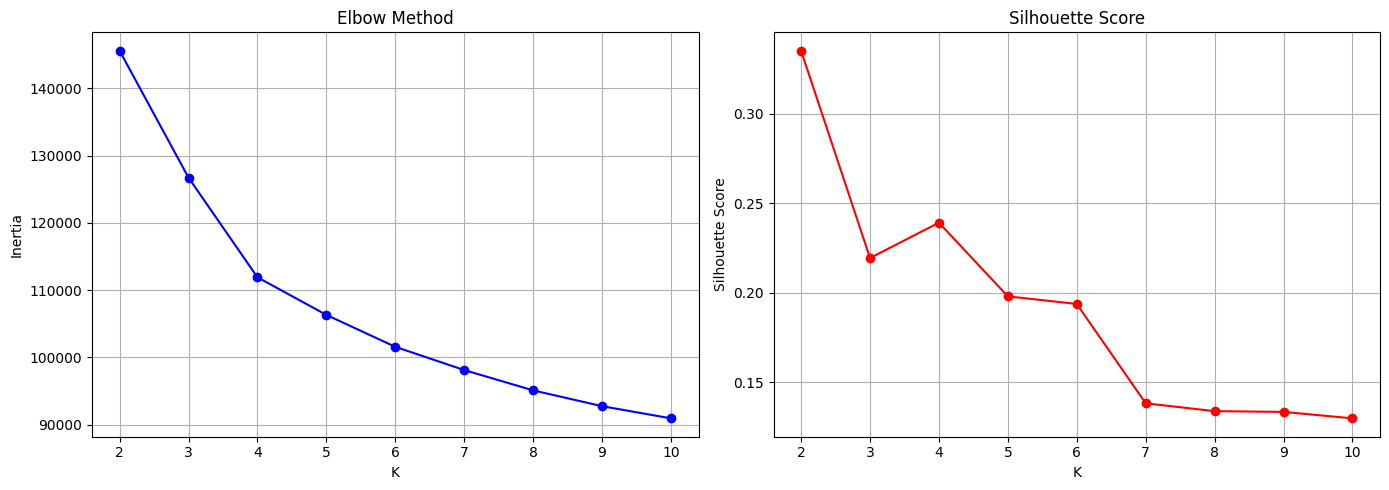

In [7]:

#Best K
inertia    = []
silhouette = []
k_range    = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters= k,
                random_state= 42,
                n_init= 10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

fig,axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range,inertia, 'bo-')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True)

axes[1].plot(k_range, silhouette, 'ro-')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

=== Profilo medio per cluster ===
         tenure  MonthlyCharges  TotalCharges
cluster                                      
0         55.13           89.64       4943.28
1         30.67           21.08        665.22
2         16.27           67.29       1071.99

=== Dimensione cluster ===
cluster
0    2360
1    1520
2    3152
Name: count, dtype: int64

=== Churn rate per cluster ===
cluster
0    0.154
1    0.074
2    0.442
Name: Churn, dtype: float64


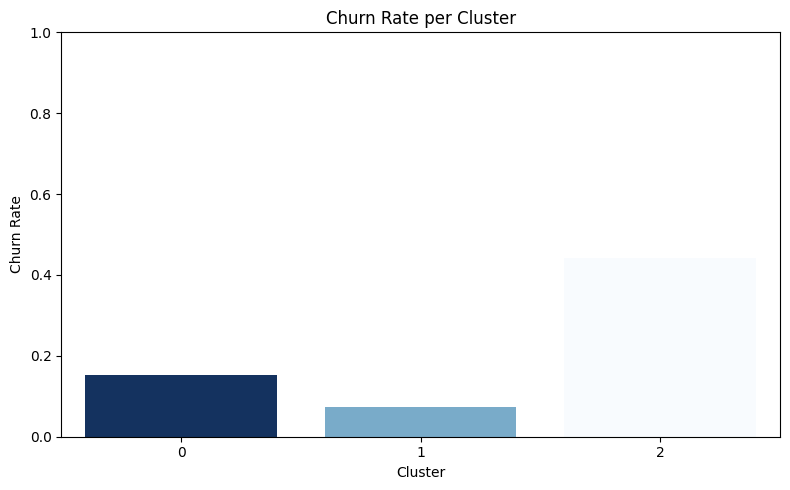

In [8]:
#finalmodel
km = KMeans(n_clusters= 3,
            random_state=42,
            n_init= 10)

df['cluster'] = km.fit_predict(X_scaled)

#clusters analysis
print("=== Profilo medio per cluster ===")
print(df.groupby('cluster')[continuous_cols].mean().round(2))

#clusters dimentions
print("\n=== Dimensione cluster ===")
print(df['cluster'].value_counts().sort_index())

#Churn rate for clusters
print("\n=== Churn rate per cluster ===")
print(df.groupby('cluster')['Churn'].mean().round(3))

#visualization
churn_rate = df.groupby('cluster')['Churn'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=churn_rate.index,
            y=churn_rate.values,
            palette='Blues_r',
            hue=churn_rate.index,
            legend=False)
plt.title('Churn Rate per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 📊 K-Means Clustering Analysis — Telco Customer Churn

---

## Profilo dei Cluster

| Cluster | Tenure (mesi) | MonthlyCharges | TotalCharges | Churn Rate | Dimensione |
|---|---|---|---|---|---|
| 0 — Premium Stabili 🟡 | 55.13 | €89.64 | €4943.28 | 15.4% | 2360 |
| 1 — Clienti Fedeli 🟢 | 30.67 | €21.08 | €665.22 | 7.4% | 1520 |
| 2 — Clienti a Rischio 🔴 | 16.27 | €67.29 | €1071.99 | 44.2% | 3152 |

---

## Interpretazione dei Cluster

### 🟢 Cluster 1 — "Clienti Fedeli"
- **Tenure media:** 30 mesi
- **Spesa mensile:** €21 — la più bassa
- **Churn rate: 7.4%** — bassissimo
- **Profilo:** clienti con contratti base, soddisfatti del servizio,
  bassa propensione all'abbandono

### 🟡 Cluster 0 — "Clienti Premium Stabili"
- **Tenure media:** 55 mesi — i più anziani
- **Spesa mensile:** €89 — la più alta
- **Churn rate: 15.4%** — moderato
- **Profilo:** clienti di lungo periodo con molti servizi attivi.
  La spesa alta riflette l'accumulo di servizi nel tempo
  (OnlineSecurity, StreamingTV, DeviceProtection...)

### 🔴 Cluster 2 — "Clienti a Rischio" ⚠️
- **Tenure media:** 16 mesi — i più nuovi
- **Spesa mensile:** €67 — media-alta
- **Churn rate: 44.2%** — quasi 1 cliente su 2 abbandona!
- **Profilo:** nuovi clienti entrati con pacchetti premium
  ma non ancora fidelizzati. Le alte aspettative
  generate dal prezzo elevato, se deluse, accelerano il churn.

---

## 🔍 Analisi: Tenure e Spesa

La relazione tra anzianità e spesa mensile segue un pattern chiaro:

| Cluster | Tenure | Spesa | Interpretazione |
|---|---|---|---|
| Fedeli 🟢 | 30 mesi | €21/mese | Entrati con piano base, rimasti fedeli |
| Premium 🟡 | 55 mesi | €89/mese | Aggiunto servizi nel tempo |
| Rischio 🔴 | 16 mesi | €67/mese | Subito su pacchetti premium — instabili |

> **Insight chiave:** la spesa cresce con la tenure.
> I clienti nuovi che spendono già molto
> hanno aspettative alte e sono i più vulnerabili.

---

## 🎯 Strategia di Retention — Focus Cluster 2

Il Cluster 2 è il segmento prioritario:
**3152 clienti** (il gruppo più numeroso) con **44% churn rate**.

| Azione | Timing | Obiettivo |
|---|---|---|
| Onboarding personalizzato | Primi 30 giorni | Ridurre il time-to-value |
| Customer success proattivo | Mesi 1-6 | Intercettare insoddisfazione precoce |
| Offerte di lock-in | Mese 3 | Convertire a contratti annuali |
| Survey di soddisfazione | Mesi 3 e 6 | Monitorare NPS e segnali di rischio |

---

## 💡 Conclusioni

```python
# I 3 segmenti identificati supportano 3 strategie distinte:
# 
# Cluster 1 (Fedeli)   → mantenimento: no intervento urgente
# Cluster 0 (Premium)  → upselling: proponi servizi aggiuntivi  
# Cluster 2 (Rischio)  → retention: intervento immediato
```

> Il clustering non predice il churn individuale,
> ma identifica **dove concentrare le risorse**
> per massimizzare l'impatto della strategia di retention.

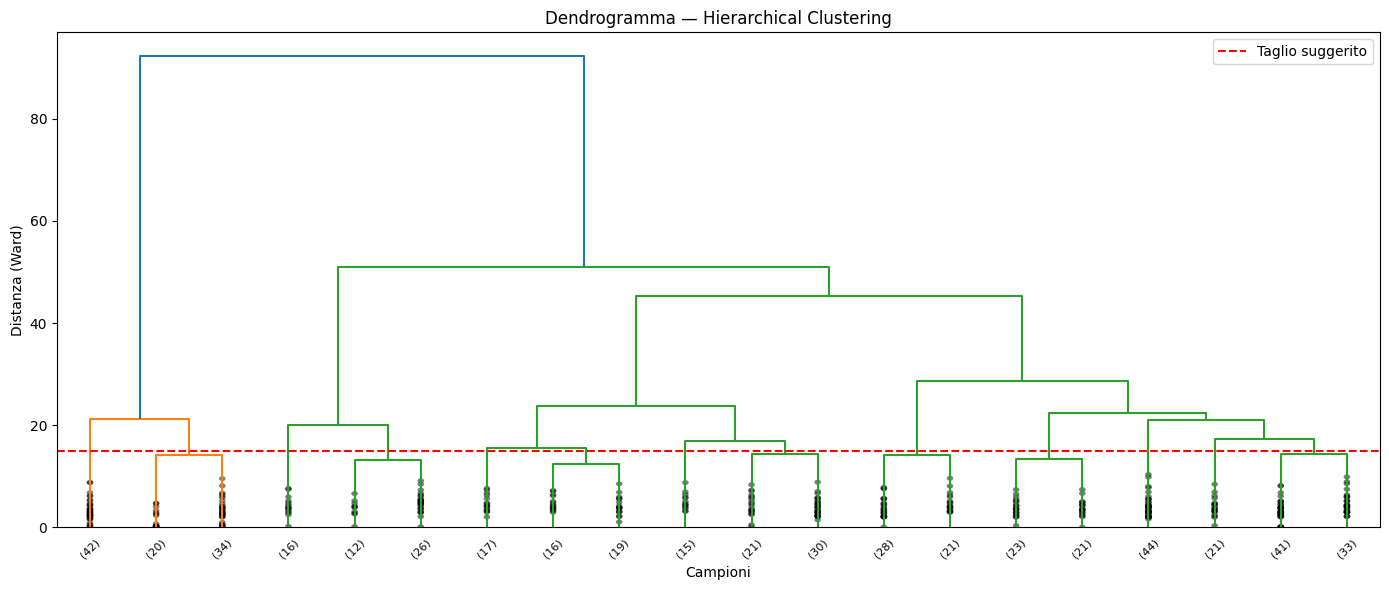

In [9]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns

#dendrogramm
sample = X_scaled[:500]

linked = linkage(sample, method= 'ward')

plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    truncate_mode= 'lastp',
    p= 20,
    leaf_rotation=45,
    leaf_font_size=8,
    show_contracted=True
)
plt.title('Dendrogramma — Hierarchical Clustering')
plt.xlabel('Campioni')
plt.ylabel('Distanza (Ward)')
plt.axhline(y=15, color='r',
            linestyle='--',
            label='Taglio suggerito')
plt.legend()
plt.tight_layout()
plt.show()




=== Profilo medio per cluster ===
            tenure  MonthlyCharges  TotalCharges
cluster_hc                                      
0            33.06           81.76       2902.47
1            30.67           21.08        665.22
2            31.83           41.99       1500.43

=== Dimensione cluster ===
cluster_hc
0    4832
1    1520
2     680
Name: count, dtype: int64

=== Churn rate per cluster ===
cluster_hc
0    0.328
1    0.074
2    0.250
Name: Churn, dtype: float64

Silhouette K-Means:      0.219
Silhouette Hierarchical: 0.289
Difference:              0.069
Better model:            Hierarchical


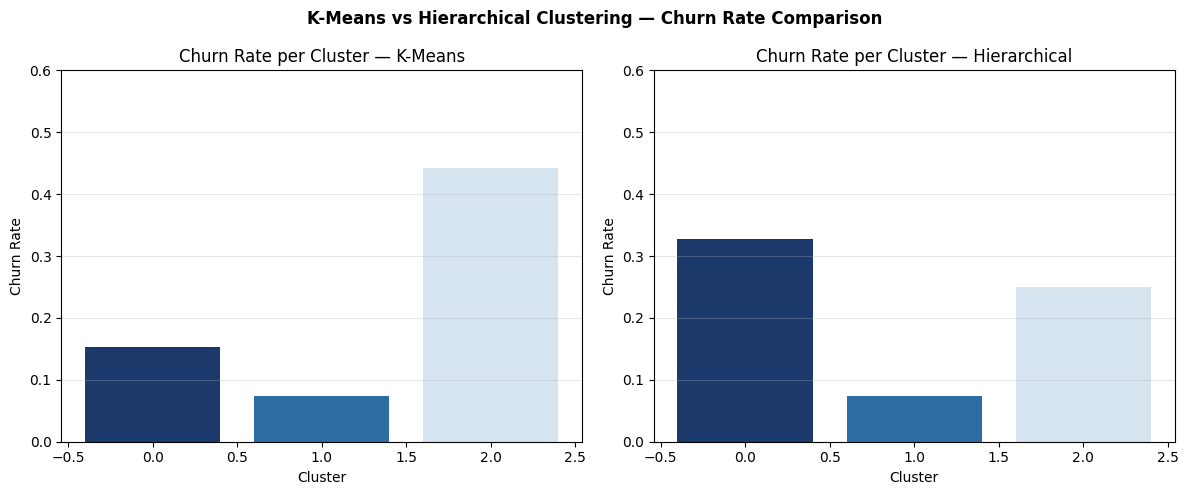

In [10]:
#final moldel with k=3
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

df['cluster_hc'] = hc.fit_predict(X_scaled)

#cluster analysis
print("=== Profilo medio per cluster ===")
print(df.groupby('cluster_hc')[continuous_cols].mean().round(2))

print("\n=== Dimensione cluster ===")
print(df['cluster_hc'].value_counts().sort_index())

print("\n=== Churn rate per cluster ===")
print(df.groupby('cluster_hc')['Churn'].mean().round(3))

#k-means vs hierarchical
from sklearn.metrics import silhouette_score

sil_kmeans = silhouette_score(X_scaled, df['cluster'])
sil_hc     = silhouette_score(X_scaled, df['cluster_hc'])

print(f"\nSilhouette K-Means:      {sil_kmeans:.3f}")
print(f"Silhouette Hierarchical: {sil_hc:.3f}")
print(f"Difference:              {abs(sil_kmeans - sil_hc):.3f}")
print(f"Better model:            {'K-Means' if sil_kmeans > sil_hc else 'Hierarchical'}")

# ── VISUAL COMPARISON ────────────────────────────────────────────────
# Side by side churn rate comparison between the two methods

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K-Means churn rate
churn_km = df.groupby('cluster')['Churn'].mean()
axes[0].bar(churn_km.index, churn_km.values,
            color=['#1B3A6B', '#2E6DA4', '#D6E4F0'])
axes[0].set_title('Churn Rate per Cluster — K-Means')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Churn Rate')
axes[0].set_ylim(0, 0.6)
axes[0].grid(axis='y', alpha=0.3)

# Hierarchical churn rate
churn_hc = df.groupby('cluster_hc')['Churn'].mean()
axes[1].bar(churn_hc.index, churn_hc.values,
            color=['#1B3A6B', '#2E6DA4', '#D6E4F0'])
axes[1].set_title('Churn Rate per Cluster — Hierarchical')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Churn Rate')
axes[1].set_ylim(0, 0.6)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('K-Means vs Hierarchical Clustering — Churn Rate Comparison',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 📊 Hierarchical Clustering Analysis — Telco Customer Churn

---

## Confronto Silhouette Score

| Modello | Silhouette Score | Differenza |
|---|---|---|
| K-Means | 0.219 | — |
| **Hierarchical** | **0.289** | +0.069 ✅ |

> Hierarchical crea cluster più compatti e meglio separati.
> Una differenza > 0.05 è considerata significativa.

---

## Profilo Cluster — Hierarchical

| Cluster | Tenure (mesi) | MonthlyCharges | TotalCharges | Churn Rate | Dimensione |
|---|---|---|---|---|---|
| 0 — Alto Spenditori 🔴 | 33.06 | €81.76 | €2902.47 | 32.8% | 4832 |
| 1 — Clienti Fedeli 🟢 | 30.67 | €21.08 | €665.22 | 7.4% | 1520 |
| 2 — Clienti Medi 🟡 | 31.83 | €41.99 | €1500.43 | 25.0% | 680 |

---

## Interpretazione dei Cluster

### 🔴 Cluster 0 — "Alto Spenditori a Rischio"
- **Spesa:** €81/mese — la più alta
- **Churn rate: 32.8%** — il più critico
- **Dimensione:** 4832 clienti — il gruppo più numeroso
- **Ipotesi:** clienti che pagano molto ma non percepiscono
  valore adeguato → aspettative alte, soddisfazione bassa

### 🟢 Cluster 1 — "Clienti Fedeli Low Cost"
- **Spesa:** €21/mese — la più bassa
- **Churn rate: 7.4%** — quasi nessun abbandono
- **Dimensione:** 1520 clienti
- **Ipotesi:** clienti soddisfatti con piano base,
  bassa esposizione al rischio churn

### 🟡 Cluster 2 — "Clienti Medi Instabili"
- **Spesa:** €41/mese — media
- **Churn rate: 25%** — moderato
- **Dimensione:** 680 clienti — gruppo piccolo
- **Ipotesi:** clienti in bilico, potrebbero
  evolvere verso fedeltà o abbandono

---

## 🔍 Differenze con K-Means

| | K-Means | Hierarchical |
|---|---|---|
| Separazione principale | Tenure (anzianità) | Spesa mensile |
| Churn rate massimo | 44.2% | 32.8% |
| Lettura | Struttura temporale | Struttura economica |
| Silhouette | 0.219 | 0.289 |

> **Insight chiave:** Hierarchical non ha trovato differenze
> di tenure tra i cluster (33, 30, 31 mesi — quasi identiche).
> La vera variabile discriminante è la **spesa mensile**,
> non l'anzianità del cliente.

---

## 💡 Conclusione — Quale modello scegliere?

Hierarchical è **matematicamente migliore** (Silhouette 0.289 vs 0.219).

Tuttavia K-Means ha prodotto un insight **più actionable**:
il cluster con 44% churn è un target più netto
per interventi di retention rispetto al 33% di Hierarchical.

> **Lezione chiave:** il Silhouette Score non è l'unico
> criterio di scelta. Un modello matematicamente peggiore
> può produrre risultati più utili per il business.
> **Il contesto decide.**

### Raccomandazione finale

| Obiettivo | Modello |
|---|---|
| Esplorazione iniziale — quanti cluster? | **Hierarchical** |
| Segmentazione operativa e retention | **K-Means** |
| Dataset grandi (> 5000 righe) | **K-Means** |
| Analisi accademica o ricerca | **Hierarchical** |